# 04 — Full Pipeline Integration

```
Noisy Image -> ConvVAE Healer -> ResNet-18 Expert -> Prediction
```

This notebook validates end-to-end inference with saved models (GPU when available, CPU fallback).

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
import os
os.chdir(Path('..').resolve())


sys.path.append(str(Path('..').resolve()))
torch.manual_seed(42)
np.random.seed(42)

In [2]:
from src.classifier import get_classifier
from src.conv_vae import ConvVAE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

with open('configs/config.yaml', 'r', encoding='utf-8') as file:
    config = yaml.safe_load(file)

vae = ConvVAE(latent_dim=config['vae']['latent_dim']).to(device)
vae.load_state_dict(torch.load('models/conv_vae_best.pth', map_location=device))
vae.eval()

classifier = get_classifier(config).to(device)
classifier.load_state_dict(torch.load('models/resnet_classifier.pth', map_location=device))
classifier.eval()

print('Loaded models: conv_vae_best.pth and resnet_classifier.pth')


Using device: cuda
Loaded models: conv_vae_best.pth and resnet_classifier.pth


In [3]:
from src.pipeline import SelfHealingPipeline

pipeline = SelfHealingPipeline(vae=vae, classifier=classifier, device=str(device))
print(f'Pipeline initialized on {device}')

Pipeline initialized on cuda


Dataset root: C:\Users\Akash\Desktop\SelfHealingNN\data\raw
Single sample load: 0.90 ms
Pipeline inference: 302.72 ms


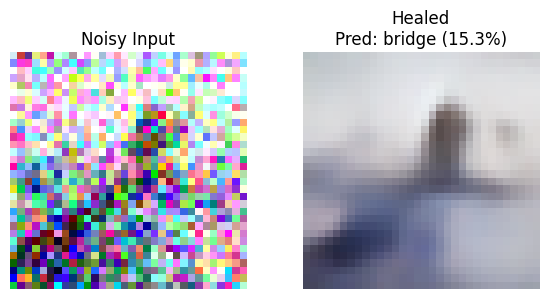

Top-5 predictions:
- bridge: 15.32%
- seal: 14.02%
- cloud: 5.03%
- skyscraper: 5.03%
- castle: 4.41%


In [4]:
from torchvision import datasets, transforms

from src.dataset import NoiseInjector

mean = config['dataset']['mean']
std = config['dataset']['std']

# Ensure notebook uses project-level dataset path, not notebooks/data/raw.

print('Dataset root:', Path(config['dataset']['root']).resolve())

def denorm(batch):
    if batch.dim() == 3:
        batch = batch.unsqueeze(0)
    mean_t = torch.tensor(mean, dtype=batch.dtype).view(1, 3, 1, 1)
    std_t = torch.tensor(std, dtype=batch.dtype).view(1, 3, 1, 1)
    denormed = torch.clamp(batch * std_t + mean_t, 0.0, 1.0)
    return denormed.squeeze(0) if denormed.size(0) == 1 else denormed

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])
dataset_root = Path(config['dataset']['root']).expanduser().resolve()
test_base = datasets.CIFAR100(root=str(dataset_root), train=False, transform=eval_transform, download=False)

start = time.perf_counter()
clean_norm, _ = test_base[0]
sample_ms = (time.perf_counter() - start) * 1000
clean_pixel = denorm(clean_norm)

injector = NoiseInjector()
noisy_pixel = injector.gaussian_noise(clean_pixel, std=0.3).unsqueeze(0)

start = time.perf_counter()
result = pipeline.forward(noisy_pixel)
inference_ms = (time.perf_counter() - start) * 1000

print(f'Single sample load: {sample_ms:.2f} ms')
print(f'Pipeline inference: {inference_ms:.2f} ms')

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(noisy_pixel[0].permute(1, 2, 0).cpu())
axes[0].set_title('Noisy Input')
axes[0].axis('off')

axes[1].imshow(result['cleaned_image'][0].detach().cpu().permute(1, 2, 0).clamp(0, 1))
axes[1].set_title(
    f"Healed\nPred: {result['class_name']} ({result['confidence'] * 100:.1f}%)"
)
axes[1].axis('off')
plt.tight_layout()
plt.show()

print('Top-5 predictions:')
for item in result['top5']:
    print(f"- {item['class_name']}: {item['confidence'] * 100:.2f}%")

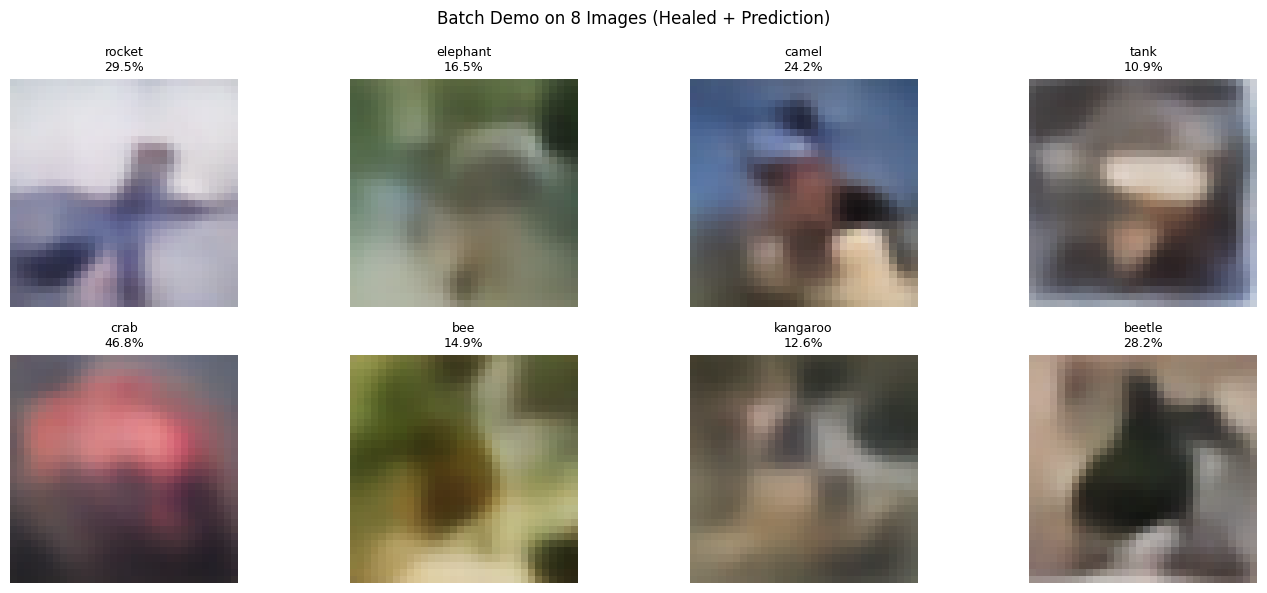

In [5]:
clean_norm_batch = torch.stack([test_base[i][0] for i in range(8)])
clean_pixel_batch = denorm(clean_norm_batch)
noisy_batch = torch.stack([injector.gaussian_noise(img, std=0.3) for img in clean_pixel_batch])

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(8):
    result_i = pipeline.forward(noisy_batch[i:i+1])
    pred_text = f"{result_i['class_name']}\n{result_i['confidence'] * 100:.1f}%"

    ax = axes[i // 4, i % 4]
    ax.imshow(result_i['cleaned_image'][0].detach().cpu().permute(1, 2, 0).clamp(0, 1))
    ax.set_title(pred_text, fontsize=9)
    ax.axis('off')

plt.suptitle('Batch Demo on 8 Images (Healed + Prediction)')
plt.tight_layout()
plt.show()

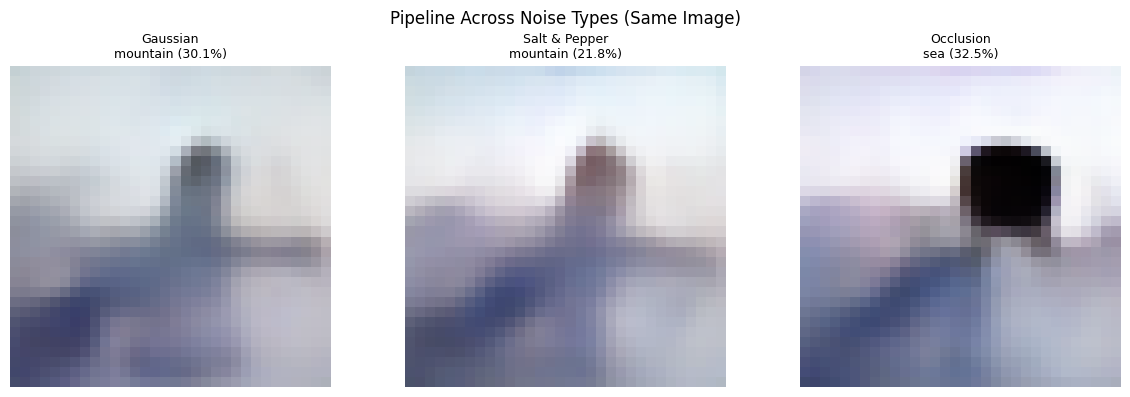

In [6]:
sample = clean_pixel
variants = {
    'Gaussian': injector.gaussian_noise(sample, std=0.3),
    'Salt & Pepper': injector.salt_pepper(sample, prob=0.05),
    'Occlusion': injector.occlusion(sample, patch_size=8),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, noisy_img) in zip(axes, variants.items()):
    out = pipeline.forward(noisy_img.unsqueeze(0))
    ax.imshow(out['cleaned_image'][0].detach().cpu().permute(1, 2, 0).clamp(0, 1))
    ax.set_title(f"{name}\n{out['class_name']} ({out['confidence'] * 100:.1f}%)", fontsize=9)
    ax.axis('off')

plt.suptitle('Pipeline Across Noise Types (Same Image)')
plt.tight_layout()
plt.show()

In [7]:
single_input = noisy_batch[0:1]
batch_input = noisy_batch.repeat(4, 1, 1, 1)[:32]

start = time.perf_counter()
_ = pipeline.forward(single_input)
single_ms = (time.perf_counter() - start) * 1000

start = time.perf_counter()
for i in range(batch_input.size(0)):
    _ = pipeline.forward(batch_input[i:i+1])
batch_ms = (time.perf_counter() - start) * 1000

print(f'Single image (heal + classify): {single_ms:.2f} ms')
print(f'Batch of 32 images total time: {batch_ms:.2f} ms')
print(f'Average per image in batch: {batch_ms / 32:.2f} ms')

Single image (heal + classify): 9.58 ms
Batch of 32 images total time: 142.78 ms
Average per image in batch: 4.46 ms


## Summary

The complete self-healing pipeline is integrated and tested with saved checkpoints.

- Single-image and batch inference are functional.
- All three corruption types are supported end-to-end.
- Predictions include class name, confidence, and Top-5 probabilities.